## 条件付き拡散モデル

+ 実用的には, p(x)よりp(x|y=条件)をモデル化する方が望まれる.
+ y=条件(テキスト, 画像, 音声, など)によって, xの生成を制御できる

### ラベル(数値)を条件yとするP(x|y)による画像生成をする条件付き拡散モデル

In [80]:
import math
import torch
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline
from torchvision import transforms as TT
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

正弦波位置エンコーディング

In [81]:
def _pos_encoding(t: torch.Tensor, output_dim: int, device='cuda'):
    D = output_dim
    v = torch.zeros(D, device=device)

    i = torch.arange(0, D, device=device)
    div_term = 10000**(i/D)

    v[0::2] = torch.sin(t / div_term[0::2])
    v[1::2] = torch.cos(t / div_term[1::2])

    return v

# バッチ型の正弦波位置エンコーディング
def pos_encoding(ts: torch.Tensor, output_dim: int, device='cuda'):
    batch_size = len(ts)
    v = torch.zeros(batch_size, output_dim, device=device)
    for i in range(batch_size):
        v[i] = _pos_encoding(ts[i], output_dim, device)
    return v

### 正弦波位置エンコーディングConvBlock

In [82]:
class PosEncConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_embed_dim, device: str):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1, device=device),
            nn.BatchNorm2d(num_features=out_ch, device=device),
            nn.ReLU(),
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1, device=device),
            nn.BatchNorm2d(num_features=out_ch, device=device),
            nn.ReLU()
        )
        
        # 正弦波位置エンコーディングの非線形変換
        self.mlp = nn.Sequential(
            nn.Linear(in_features=time_embed_dim, out_features=in_ch, device=device),
            nn.ReLU(),
            nn.Linear(in_features=in_ch, out_features=in_ch, device=device)
        )

    def forward(self, x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        N, C, _, _ = x.shape
        v = self.mlp(v)
        v = v.view(N, C, 1, 1) # (N, C) -> (N, C, 1, 1)
        y = self.convs(x + v) # Input + Pos Enc
        return y

### 条件付き拡散モデル用UNet

In [83]:
from winreg import KEY_CREATE_LINK


class ConditionalTimeStepUNet(nn.Module):
    def __init__(self,
                 in_ch: int = 1,
                 time_embed_dim: int = 100,
                 num_labels: int | None = None,
                 device: str = "cuda",
                 ):
        super().__init__()
        self.time_embed_dim: int = time_embed_dim

        self.down1 = PosEncConvBlock(in_ch, 64, time_embed_dim, device=device)
        self.down2 = PosEncConvBlock(64, 128, time_embed_dim, device=device)
        self.bottom = PosEncConvBlock(128, 256, time_embed_dim, device=device)
        self.up2 = PosEncConvBlock(128 + 256, 128, time_embed_dim, device=device)
        self.up1 = PosEncConvBlock(128 + 64, 64, time_embed_dim, device=device)
        self.out = nn.Conv2d(64, in_ch, kernel_size=1, stride=1, padding=0, dilation=1, groups=1, device=device)

        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

        
        # ラべrうを処理する埋め込み層(条件num_labels(int)を埋め込みベクトルに変換)
        if num_labels is not None:
            self.label_emb = nn.Embedding(num_embeddings=num_labels, embedding_dim=time_embed_dim, device=device)
        
    def forward(self, x: torch.Tensor, 
                timesteps: torch.Tensor, 
                labels: torch.Tensor | None = None) -> torch.Tensor:

        # print(f"timesteps.device: {timesteps.device}")
        

        t: torch.Tensor = pos_encoding(timesteps, self.time_embed_dim)

        # print(f"pos_enc t.device: {t.device}")

        # ラベル処理
        if labels is not None:
            # print(f"labels.device: {labels.device}")
            condition = self.label_emb(labels)
            # print(f"condition.device: {condition.device}")
            t += condition
        
        x1 = self.down1(x, t)
        x = self.maxpool(x1)
        x2 = self.down2(x, t)
        x = self.maxpool(x2)

        x = self.bottom(x, t)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, t)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, t)
        x = self.out(x)
        return x

In [84]:
class ConditionalDiffuser:
    def __init__(self,
                 num_timesteps: int = 1000,
                 beta_start: float = 0.0001,
                 beta_end: float = 0.02,
                 device = 'cuda'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0) # 累積積

    def add_noise(self, x_0: torch.Tensor, t: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= self.num_timesteps).all()
        t_idx = t - 1

        alpha_bar = self.alpha_bars[t_idx]
        N = alpha_bar.size(0)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)

        noise = torch.randn_like(x_0, device=self.device)
        x_t: torch.Tensor = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise

        return x_t, noise
    
    def denoise(self, 
                model, x: torch.Tensor, 
                t: torch.Tensor,
                condition_labels: torch.Tensor,
                ) -> torch.Tensor:
        # tの各要素が1以上かつT以下であることを確認
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1
        alpha = self.alphas[t_idx]
        alpha_bar = self.alpha_bars[t_idx]
        alpha_bar_prev = self.alpha_bars[t_idx - 1]

        # ブロードキャストが正しく行われるための設定
        N = alpha.size(0)
        alpha = alpha.view(N, 1, 1, 1)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(N, 1, 1, 1)

        model.eval() # BatchNormやDropoutなどtrainとevalで挙動が異なる演算を考慮
        with torch.no_grad():
            output_eps_of_model = model(x, t, condition_labels) # ConditionalTimeStepUNet

        model.train()

        noise = torch.randn_like(x, device=self.device)
        noise[t == 1] = 0 # T=1のとき, epsを0にする

        mu = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * output_eps_of_model) / torch.sqrt(alpha)
        std = torch.sqrt((1 - alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar))
        return mu + std * noise
    
    def reverse_to_img(self, x: torch.Tensor):
        x = x * 255
        x = x.clamp(0, 255)
        x = x.to(torch.uint8)
        x = x.cpu()
        to_pil = TT.ToPILImage()
        return to_pil(x)
    
    def sample(self, 
               model, 
               x_shape=(20, 1, 28, 28),
               labels: torch.Tensor | None = None):
        batch_size = x_shape[0]
        x = torch.randn(x_shape, device=self.device)

        if labels is None:
            labels = torch.randint(0, 10, (len(x),), device=self.device)

        for i in tqdm(range(self.num_timesteps, 0, -1)):
            t = torch.tensor([i] * batch_size, device=self.device, dtype=torch.long) # バッチサイズ分のT
            x = self.denoise(model, x, t, labels)

        images = [self.reverse_to_img(x[i]) for i in range(batch_size)]
        return images, labels


In [85]:
def show_images(images, rows=2, cols=10):
    fig = plt.figure(figsize=(cols, rows))
    i = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.axis('off') # 縦軸/横軸を非表示にする
            i += 1
    plt.show()

学習

100%|██████████| 469/469 [01:02<00:00,  7.52it/s]


Epoch 0 | Loss: 0.04830735546550644


100%|██████████| 469/469 [01:02<00:00,  7.44it/s]


Epoch 1 | Loss: 0.02616354884869699


100%|██████████| 469/469 [01:03<00:00,  7.44it/s]


...

Epoch 7 | Loss: 0.018008242265930945


100%|██████████| 469/469 [01:10<00:00,  6.62it/s]


Epoch 8 | Loss: 0.01805472564992747


100%|██████████| 469/469 [01:12<00:00,  6.49it/s]


Epoch 9 | Loss: 0.017524826908305383


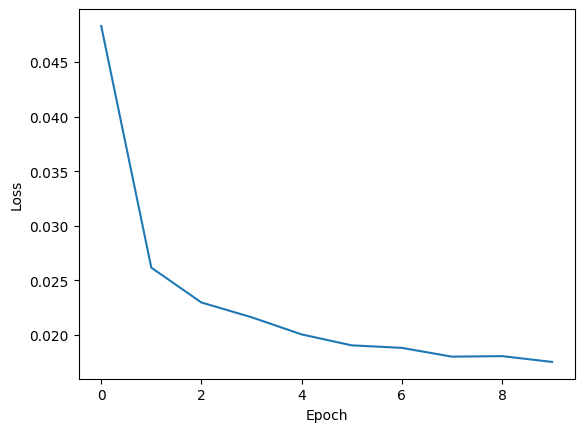

  0%|          | 0/1000 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument index in method wrapper_CUDA__index_select)

In [87]:
# MNIST
img_size = 28
batch_size = 128
num_timesteps = 1000
epochs = 10
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

preprocess = TT.ToTensor()
ds = torchvision.datasets.MNIST(root='./data', download=True, transform=preprocess)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

diffuser = ConditionalDiffuser(num_timesteps=num_timesteps, device=device)
model = ConditionalTimeStepUNet(num_labels=10, device=device)
optimizer = Adam(model.parameters(), lr=lr)

losses = []
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    for images, labels in tqdm(dl):
        optimizer.zero_grad()

        x = images.to(device)
        labels = labels.to(device) # 条件y
        t = torch.randint(1, num_timesteps + 1, (len(x), ), device=device) # 時刻t

        x_noisy, noise = diffuser.add_noise(x, t)
        # print(f"x_noisy.device: {x_noisy.device}, noise.device: {noise.device}, t.device: {t.device}")
        noise_pred = model(x_noisy, t, labels)
        loss = F.mse_loss(noise, noise_pred)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(f"Epoch {epoch} | Loss: {loss_avg}")

# 損失値のグラフ
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 画像を生成
images = diffuser.sample(model, labels=torch.LongTensor([5]))
show_images(images)
